# Feature engineering — base de modélisation `carclaims`

Ce notebook transforme le jeu brut `fraud_oracle.csv` en une base de modélisation propre, **sans fuite de données**, pour la détection d'anomalies par Isolation Forest et ses comparatifs (LOF, One-Class SVM), conformément à l'esprit de l'article de Liu, Ting & Zhou (2012).

**Ce que produit ce notebook**

- Un découpage entraînement / test **stratifié**, réalisé *avant* d'apprendre la moindre transformation dépendant des données.
- Deux représentations numériques comparables des variables catégorielles :
  - **A — one-hot** (fidèle, haute dimension), adaptée à Isolation Forest ;
  - **B — encodage fréquentiel** (compacte, tout-numérique), adaptée aux méthodes de distance / noyau.
- Pour chaque représentation, une variante **brute** et une variante **standardisée** (`StandardScaler`).
- La persistance de la représentation retenue pour la modélisation (encodage fréquentiel standardisé), sous forme de quatre CSV, dans `data/sorties/`.

**Pourquoi ces choix (rappel de l'article)**

Isolation Forest opère par isolement récursif sur des attributs *continus* : il exige une représentation numérique mais est **invariant à toute transformation monotone** — la standardisation ne lui est donc pas nécessaire. En revanche, LOF (densité/distance) et One-Class SVM (noyau RBF) reposent sur des distances euclidiennes : la standardisation y est **indispensable** pour que les attributs contribuent équitablement, hypothèse posée par l'article. On fournit donc les deux variantes.

## 0. Imports et configuration

In [1]:
from pathlib import Path
import json, inspect, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

def _find_root(start):
    for p in [start, *start.parents]:
        if (p / 'data' / 'raw' / 'fraud_oracle.csv').exists(): return p
    raise RuntimeError('Racine du projet introuvable.')
PROJECT_ROOT=_find_root(Path.cwd())

TARGET = "FraudFound_P"
ID = "PolicyNumber"

# --- Dictionnaires de domaine (fixes -> aucune fuite de données) ---------------------
MONTH_NUM = {m: i + 1 for i, m in enumerate(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])}
DAY_NUM = {d: i for i, d in enumerate(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])}

# Ordre croissant documenté de chaque variable ordinale textuelle.
ORDINAL_MAPS = {
    "VehiclePrice": ["less than 20000", "20000 to 29000", "30000 to 39000",
                     "40000 to 59000", "60000 to 69000", "more than 69000"],
    "Days_Policy_Accident": ["none", "1 to 7", "8 to 15", "15 to 30", "more than 30"],
    "Days_Policy_Claim": ["none", "8 to 15", "15 to 30", "more than 30"],
    "PastNumberOfClaims": ["none", "1", "2 to 4", "more than 4"],
    "AgeOfVehicle": ["new", "2 years", "3 years", "4 years", "5 years",
                     "6 years", "7 years", "more than 7"],
    "AgeOfPolicyHolder": ["16 to 17", "18 to 20", "21 to 25", "26 to 30", "31 to 35",
                          "36 to 40", "41 to 50", "51 to 65", "over 65"],
    "NumberOfSuppliments": ["none", "1 to 2", "3 to 5", "more than 5"],
    # ordre par ancienneté du changement d'adresse : récent -> jamais ("no change")
    "AddressChange_Claim": ["under 6 months", "1 year", "2 to 3 years", "4 to 8 years", "no change"],
    "NumberOfCars": ["1 vehicle", "2 vehicles", "3 to 4", "5 to 8", "more than 8"],
}

# Variables nominales (sans ordre). PolicyType est volontairement exclu : il est le
# produit déterministe de VehicleCategory × BasePolicy (V de Cramér = 1).
NOMINAL = ["Make", "AccidentArea", "Sex", "MaritalStatus", "Fault",
           "VehicleCategory", "BasePolicy", "PoliceReportFiled", "WitnessPresent", "AgentType"]


def build_features(data: pd.DataFrame) -> pd.DataFrame:
    """Transformations déterministes (dictionnaires fixes, arithmétique, indicateurs).

    N'apprend rien des données -> applicable au train et au test séparément sans fuite.
    """
    d = data.copy()

    # Codes de date invalides '0' -> manquant (imputé plus tard)
    d["MonthClaimed"] = d["MonthClaimed"].replace("0", np.nan)
    d["DayOfWeekClaimed"] = d["DayOfWeekClaimed"].replace("0", np.nan)

    # Age == 0 : indicateur dédié puis mise en manquant (convention de saisie, pas un âge réel)
    d["Age_is_zero"] = (d["Age"] == 0).astype("int8")
    d["Age"] = d["Age"].replace(0, np.nan)

    # Numéros de mois / jour
    ma, mc = d["Month"].map(MONTH_NUM), d["MonthClaimed"].map(MONTH_NUM)
    da, dc = d["DayOfWeek"].map(DAY_NUM), d["DayOfWeekClaimed"].map(DAY_NUM)

    # Encodage cyclique sin/cos (janvier voisin de décembre, dimanche voisin de lundi)
    for name, num, period in [("Month", ma, 12), ("MonthClaimed", mc, 12),
                              ("DayOfWeek", da, 7), ("DayOfWeekClaimed", dc, 7)]:
        d[f"{name}_sin"] = np.sin(2 * np.pi * num / period)
        d[f"{name}_cos"] = np.cos(2 * np.pi * num / period)

    # Délais approximatifs accident -> déclaration (cycliques)
    d["month_gap_mod12"] = (mc - ma) % 12
    d["day_gap_mod7"] = (dc - da) % 7

    # Encodage ordinal documenté
    for col, order in ORDINAL_MAPS.items():
        d[f"{col}_ord"] = d[col].map({v: i for i, v in enumerate(order)})

    # Suppression des colonnes sources encodées, de l'identifiant, de la cible et de PolicyType
    to_drop = (["Month", "MonthClaimed", "DayOfWeek", "DayOfWeekClaimed"]
               + list(ORDINAL_MAPS) + ["PolicyType", ID, TARGET])
    return d.drop(columns=[c for c in to_drop if c in d.columns])


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Regroupe les modalités rares (< ``min_freq``) en un token unique.

    Le regroupement ne s'applique qu'aux variables à forte cardinalité (> ``min_levels``
    modalités) : sur une binaire/ternaire, regrouper une modalité minoritaire ne réduirait
    pas la dimension et détruirait de l'information. Le seuil est appris sur le train.
    """

    def __init__(self, min_freq: float = 0.01, min_levels: int = 6, token: str = "__rare__"):
        self.min_freq = min_freq
        self.min_levels = min_levels
        self.token = token

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.frequent_ = {}
        for c in X.columns:
            freqs = X[c].value_counts(normalize=True)
            if freqs.size > self.min_levels:
                self.frequent_[c] = set(freqs.loc[lambda s: s >= self.min_freq].index)
            else:
                self.frequent_[c] = set(freqs.index)  # faible cardinalité -> tout conserver
        self.feature_names_in_ = np.array(X.columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in X.columns:
            X[c] = X[c].where(X[c].isin(self.frequent_[c]), self.token)
        return X

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Remplace chaque modalité par sa fréquence apprise sur le train.

    Une modalité inédite au test reçoit une fréquence de 0.
    """

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.freqs_ = {c: X[c].value_counts(normalize=True) for c in X.columns}
        self.feature_names_in_ = np.array(X.columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for c in X.columns:
            out[c] = X[c].map(self.freqs_[c]).fillna(0.0)
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_freq" for c in self.feature_names_in_])


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',120)
pd.set_option('display.float_format',lambda x:f'{x:,.4f}')
sns.set_theme(style='whitegrid',context='notebook',font_scale=1.05)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8FAFC','axes.titleweight':'bold','figure.dpi':115})
NAVY,BLUE,TEAL,CORAL,GOLD='#0F172A','#2563EB','#0D9488','#F43F5E','#F59E0B'
RANDOM_STATE=42; TEST_SIZE=.25
print(f'Racine du projet : {PROJECT_ROOT}')

Racine du projet : C:\Users\hamid\Downloads\Projet_ML_iForest


## 1. Chargement du jeu brut

In [2]:
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'fraud_oracle.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'fraud_oracle.csv introuvable : {DATA_PATH}')
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'sorties'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df[TARGET] = pd.to_numeric(df[TARGET], errors='raise').astype('int8')
print(f'Jeu brut : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Taux de fraude global : {df[TARGET].mean():.2%}')
print(f'Sorties écrites dans : {OUTPUT_DIR}')

Jeu brut : 15,420 lignes × 33 colonnes
Taux de fraude global : 5.99%
Sorties écrites dans : C:\Users\hamid\Downloads\Projet_ML_iForest\data\sorties


## 2. Décisions issues de l'EDA (rappel)

La préparation applique directement les conclusions du notebook `01_eda_carclaims` :

| Élément | Décision | Justification EDA |
|---|---|---|
| `PolicyNumber` | exclure | identifiant unique à 100 %, sans pouvoir prédictif généralisable |
| `FraudFound_P` | séparer de X | étiquette réservée à l'évaluation (jamais vue par les modèles non supervisés) |
| `PolicyType` | supprimer | combinaison **déterministe** de `VehicleCategory` × `BasePolicy` (V de Cramér = 1) |
| `Month(Claimed)`, `DayOfWeek(Claimed)` | encodage cyclique sin/cos + délais mod 12 / mod 7 | décembre est voisin de janvier, dimanche de lundi |
| codes `'0'` de mois/jour de déclaration | recoder en manquant puis imputer | 1 dossier avec un code de date invalide |
| `Age == 0` | indicateur dédié + imputation médiane | convention de saisie systématique pour la tranche `16 to 17` ans, pas un âge réel |
| variables ordinales textuelles | mapping ordinal documenté | préserver l'ordre sans inventer de distance exacte |
| variables nominales | comparer one-hot et fréquentiel | Isolation Forest exige du numérique ; le one-hot brut coûte cher (140 colonnes) |
| modalités rares (`Make`) | regrouper, seuil appris **sur le train** | 11 marques sous 1 %, bruit dimensionnel |
| `Days_Policy_*` (quasi-constantes) | **conserver** | signal de fraude connu (sinistre juste après souscription) malgré la quasi-constance |

## 3. Dictionnaires de domaine

Ces correspondances sont **fixes** (connaissance métier / calendrier), indépendantes des données observées : les appliquer ne crée donc **aucune fuite**, que ce soit avant ou après le découpage. Elles sont définies dans `src/carclaims_features.py` et importées ci-dessous.

In [3]:
print('Numéros de mois :', MONTH_NUM)
print('Numéros de jour :', DAY_NUM)
print()
print('Variables ordinales et leur ordre :')
for col, order in ORDINAL_MAPS.items():
    print(f'  {col:22s} : {order}')
print()
print('Variables nominales :', NOMINAL)

Numéros de mois : {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
Numéros de jour : {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}

Variables ordinales et leur ordre :
  VehiclePrice           : ['less than 20000', '20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000', 'more than 69000']
  Days_Policy_Accident   : ['none', '1 to 7', '8 to 15', '15 to 30', 'more than 30']
  Days_Policy_Claim      : ['none', '8 to 15', '15 to 30', 'more than 30']
  PastNumberOfClaims     : ['none', '1', '2 to 4', 'more than 4']
  AgeOfVehicle           : ['new', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', 'more than 7']
  AgeOfPolicyHolder      : ['16 to 17', '18 to 20', '21 to 25', '26 to 30', '31 to 35', '36 to 40', '41 to 50', '51 to 65', 'over 65']
  NumberOfSuppliments    : ['none', '1 to 2', '3 to 5', 'more than 5']
  AddressChange_C

## 4. Construction déterministe des variables

`build_features` regroupe toutes les transformations qui **n'apprennent rien des données** (dictionnaires fixes, arithmétique, indicateurs). Elle peut donc être appliquée séparément au train et au test sans risque de fuite. Les étapes qui *apprennent* des données (regroupement des rares, encodage fréquentiel, imputation, standardisation) sont traitées plus loin, uniquement ajustées sur le train.

La fonction est définie dans `src/carclaims_features.py` ; son code est affiché ci-dessous pour transparence.

In [4]:
print('La fonction build_features est définie dans la cellule de configuration ci-dessus.')

La fonction build_features est définie dans la cellule de configuration ci-dessus.


## 5. Découpage train / test **avant** tout apprentissage

Étape critique contre la fuite de données : on sépare d'abord, puis on n'ajustera les transformations apprises que sur le train. Le découpage est **stratifié** sur la cible pour préserver le taux de fraude (~6 %) dans les deux échantillons.

In [5]:
y = df[TARGET].astype('int8')
X_raw = df.drop(columns=[TARGET])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

print(f'Train : {X_train_raw.shape[0]:,} lignes | fraude {y_train.mean():.2%}')
print(f'Test  : {X_test_raw.shape[0]:,} lignes | fraude {y_test.mean():.2%}')

Train : 11,565 lignes | fraude 5.98%
Test  : 3,855 lignes | fraude 5.99%


In [6]:
# Application des transformations déterministes, séparément (aucun paramètre appris ici)
X_train = build_features(X_train_raw)
X_test = build_features(X_test_raw)

NUMERIC = [c for c in X_train.columns if c not in NOMINAL]
print(f'{X_train.shape[1]} variables construites : {len(NUMERIC)} numériques + {len(NOMINAL)} nominales')
print(f'Valeurs manquantes à imputer (train) : {int(X_train[NUMERIC].isna().sum().sum())}')
display(X_train.head(3))

37 variables construites : 27 numériques + 10 nominales
Valeurs manquantes à imputer (train) : 237


,WeekOfMonth,Make,AccidentArea,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,VehicleCategory,RepNumber,Deductible,DriverRating,PoliceReportFiled,WitnessPresent,AgentType,Year,BasePolicy,Age_is_zero,Month_sin,Month_cos,MonthClaimed_sin,MonthClaimed_cos,DayOfWeek_sin,DayOfWeek_cos,DayOfWeekClaimed_sin,DayOfWeekClaimed_cos,month_gap_mod12,day_gap_mod7,VehiclePrice_ord,Days_Policy_Accident_ord,Days_Policy_Claim_ord,PastNumberOfClaims_ord,AgeOfVehicle_ord,AgeOfPolicyHolder_ord,NumberOfSuppliments_ord,AddressChange_Claim_ord,NumberOfCars_ord
1359,2,Honda,Urban,2,Female,Single,30.0000,Policy Holder,Sport,6,400,3,No,No,External,1994,Liability,0,-1.0000,-0.0000,-1.0000,-0.0000,0.7818,0.6235,0.7818,0.6235,0.0000,0.0000,1,4,3,1,5,4,0,4,0
12149,3,Pontiac,Urban,3,Male,Married,38.0000,Third Party,Utility,6,400,3,No,No,External,1996,All Perils,0,-0.8660,-0.5000,-0.8660,-0.5000,0.9749,-0.2225,0.4339,-0.9010,0.0000,1.0000,5,4,3,2,7,5,0,4,0
9374,1,Toyota,Urban,1,Male,Married,58.0000,Third Party,Sport,11,400,2,No,No,External,1995,Liability,0,0.5000,-0.8660,0.5000,-0.8660,0.9749,-0.2225,0.4339,-0.9010,0.0000,1.0000,1,4,3,2,6,7,2,4,0


## 6. Transformers apprenant sur le train uniquement

Deux transformers maison, compatibles scikit-learn (donc `fit` sur le train, `transform` sur les deux), sans dépendance externe, définis dans `src/carclaims_features.py` :

- `RareCategoryGrouper` : regroupe les modalités rares (< `min_freq`) en un token unique, mais seulement pour les variables à forte cardinalité (> `min_levels`). Cible ici `Make` (19 marques, dont 11 sous 1 %) sans dénaturer les binaires.
- `FrequencyEncoder` : remplace chaque modalité par sa fréquence apprise sur le train ; une modalité inédite au test reçoit 0.

Leur code est reproduit ci-dessous pour transparence.

In [7]:
print('RareCategoryGrouper et FrequencyEncoder sont définis dans la cellule de configuration ci-dessus.')

RareCategoryGrouper et FrequencyEncoder sont définis dans la cellule de configuration ci-dessus.


## 7. Représentation A — one-hot

Bloc numérique imputé (médiane) ; bloc nominal regroupé puis one-hot avec `handle_unknown='ignore'` (robuste aux modalités inédites au test). Représentation fidèle, recommandée pour Isolation Forest.

In [8]:
preprocessor_onehot = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERIC),
    ('cat', Pipeline([('rare', RareCategoryGrouper(min_freq=0.01, min_levels=6)),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     NOMINAL),
], verbose_feature_names_out=False)
preprocessor_onehot.set_output(transform='pandas')

X_train_onehot = preprocessor_onehot.fit_transform(X_train)  # fit : train uniquement
X_test_onehot = preprocessor_onehot.transform(X_test)
print(f'Représentation A (one-hot) : train {X_train_onehot.shape}, test {X_test_onehot.shape}')

Représentation A (one-hot) : train (11565, 58), test (3855, 58)

## 8. Représentation B — encodage fréquentiel

Mêmes variables numériques ; bloc nominal remplacé par la fréquence de chaque modalité. Représentation compacte et entièrement numérique, adaptée aux méthodes de distance / noyau.

In [9]:
preprocessor_freq = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERIC),
    ('cat', Pipeline([('rare', RareCategoryGrouper(min_freq=0.01, min_levels=6)),
                      ('freq', FrequencyEncoder())]), NOMINAL),
], verbose_feature_names_out=False)
preprocessor_freq.set_output(transform='pandas')

X_train_freq = preprocessor_freq.fit_transform(X_train)
X_test_freq = preprocessor_freq.transform(X_test)
print(f'Représentation B (fréquentiel) : train {X_train_freq.shape}, test {X_test_freq.shape}')

Représentation B (fréquentiel) : train (11565, 37), test (3855, 37)

## 9. Variantes standardisées

Le `StandardScaler` est ajusté **sur le train** puis appliqué au test.

- **A** : on ne standardise que le bloc numérique ; les indicatrices one-hot restent en 0/1 (standardiser des binaires rares les sur-pondérerait artificiellement).
- **B** : tout est numérique, on standardise l'ensemble.

**Rappel d'usage** — Isolation Forest : variantes brutes (invariance monotone). LOF / One-Class SVM : variantes standardisées (distances/noyau).

In [10]:
# A : standardiser uniquement le bloc numérique, laisser les indicatrices intactes
dummy_cols = [c for c in X_train_onehot.columns if c not in NUMERIC]
scaler_onehot = StandardScaler().fit(X_train_onehot[NUMERIC])
X_train_onehot_scaled = X_train_onehot.copy()
X_test_onehot_scaled = X_test_onehot.copy()
X_train_onehot_scaled[NUMERIC] = scaler_onehot.transform(X_train_onehot[NUMERIC])
X_test_onehot_scaled[NUMERIC] = scaler_onehot.transform(X_test_onehot[NUMERIC])

# B : standardiser l'intégralité de la matrice
scaler_freq = StandardScaler().fit(X_train_freq)
X_train_freq_scaled = pd.DataFrame(scaler_freq.transform(X_train_freq),
                                   columns=X_train_freq.columns, index=X_train_freq.index)
X_test_freq_scaled = pd.DataFrame(scaler_freq.transform(X_test_freq),
                                  columns=X_test_freq.columns, index=X_test_freq.index)
print('Variantes standardisées prêtes.')
print(f'A : {len(dummy_cols)} indicatrices laissées en 0/1, {len(NUMERIC)} variables numériques standardisées')

Variantes standardisées prêtes.
A : 31 indicatrices laissées en 0/1, 27 variables numériques standardisées


## 10. Contrôles d'intégrité et anti-fuite

On vérifie explicitement l'absence de la cible et de l'identifiant, la cohérence des colonnes train/test, l'absence de valeurs manquantes résiduelles, et le centrage effectif des variantes standardisées.

In [11]:
checks = []
def _check(label, ok):
    checks.append((label, bool(ok)))

for name, Xtr, Xte in [('one-hot', X_train_onehot, X_test_onehot),
                       ('freq', X_train_freq, X_test_freq)]:
    _check(f'[{name}] cible/id absents', TARGET not in Xtr.columns and ID not in Xtr.columns)
    _check(f'[{name}] colonnes train==test', list(Xtr.columns) == list(Xte.columns))
    _check(f'[{name}] aucun NaN (train)', Xtr.isna().sum().sum() == 0)
    _check(f'[{name}] aucun NaN (test)', Xte.isna().sum().sum() == 0)

_check('[freq scaled] moyenne train ~0', np.allclose(X_train_freq_scaled.mean(), 0, atol=1e-9))
_check('[freq scaled] écart-type train ~1', np.allclose(X_train_freq_scaled.std(ddof=0), 1, atol=1e-6))
_check('index train/test disjoints', len(set(X_train.index) & set(X_test.index)) == 0)

report = pd.DataFrame(checks, columns=['contrôle', 'ok'])
display(report)
assert report['ok'].all(), 'Au moins un contrôle a échoué.'
print('Tous les contrôles sont passés.')

,contrôle,ok
0,[one-hot] cible/id absents,True
1,[one-hot] colonnes train==test,True
2,[one-hot] aucun NaN (train),True
3,[one-hot] aucun NaN (test),True
4,[freq] cible/id absents,True
5,[freq] colonnes train==test,True
6,[freq] aucun NaN (train),True
7,[freq] aucun NaN (test),True
8,[freq scaled] moyenne train ~0,True
9,[freq scaled] écart-type train ~1,True


Tous les contrôles sont passés.


## 11. Aperçu des variables finales

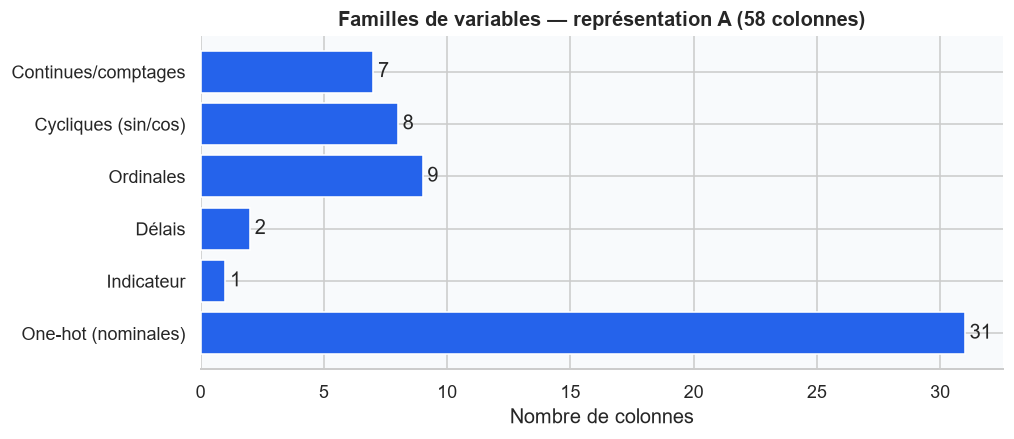

In [12]:
# Répartition des variables par famille (représentation A)
cyclic = [c for c in NUMERIC if c.endswith(('_sin', '_cos'))]
ordinal = [c for c in NUMERIC if c.endswith('_ord')]
delays = ['month_gap_mod12', 'day_gap_mod7']
indic = ['Age_is_zero']
cont = [c for c in NUMERIC if c not in cyclic + ordinal + delays + indic]
groups = {'Continues/comptages': len(cont), 'Cycliques (sin/cos)': len(cyclic),
          'Ordinales': len(ordinal), 'Délais': len(delays), 'Indicateur': len(indic),
          'One-hot (nominales)': len(dummy_cols)}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(groups)[::-1], list(groups.values())[::-1], color=BLUE)
ax.bar_label(bars, padding=3)
ax.set(title=f'Familles de variables — représentation A ({X_train_onehot.shape[1]} colonnes)',
       xlabel='Nombre de colonnes')
sns.despine(left=True)
plt.tight_layout(); plt.show()

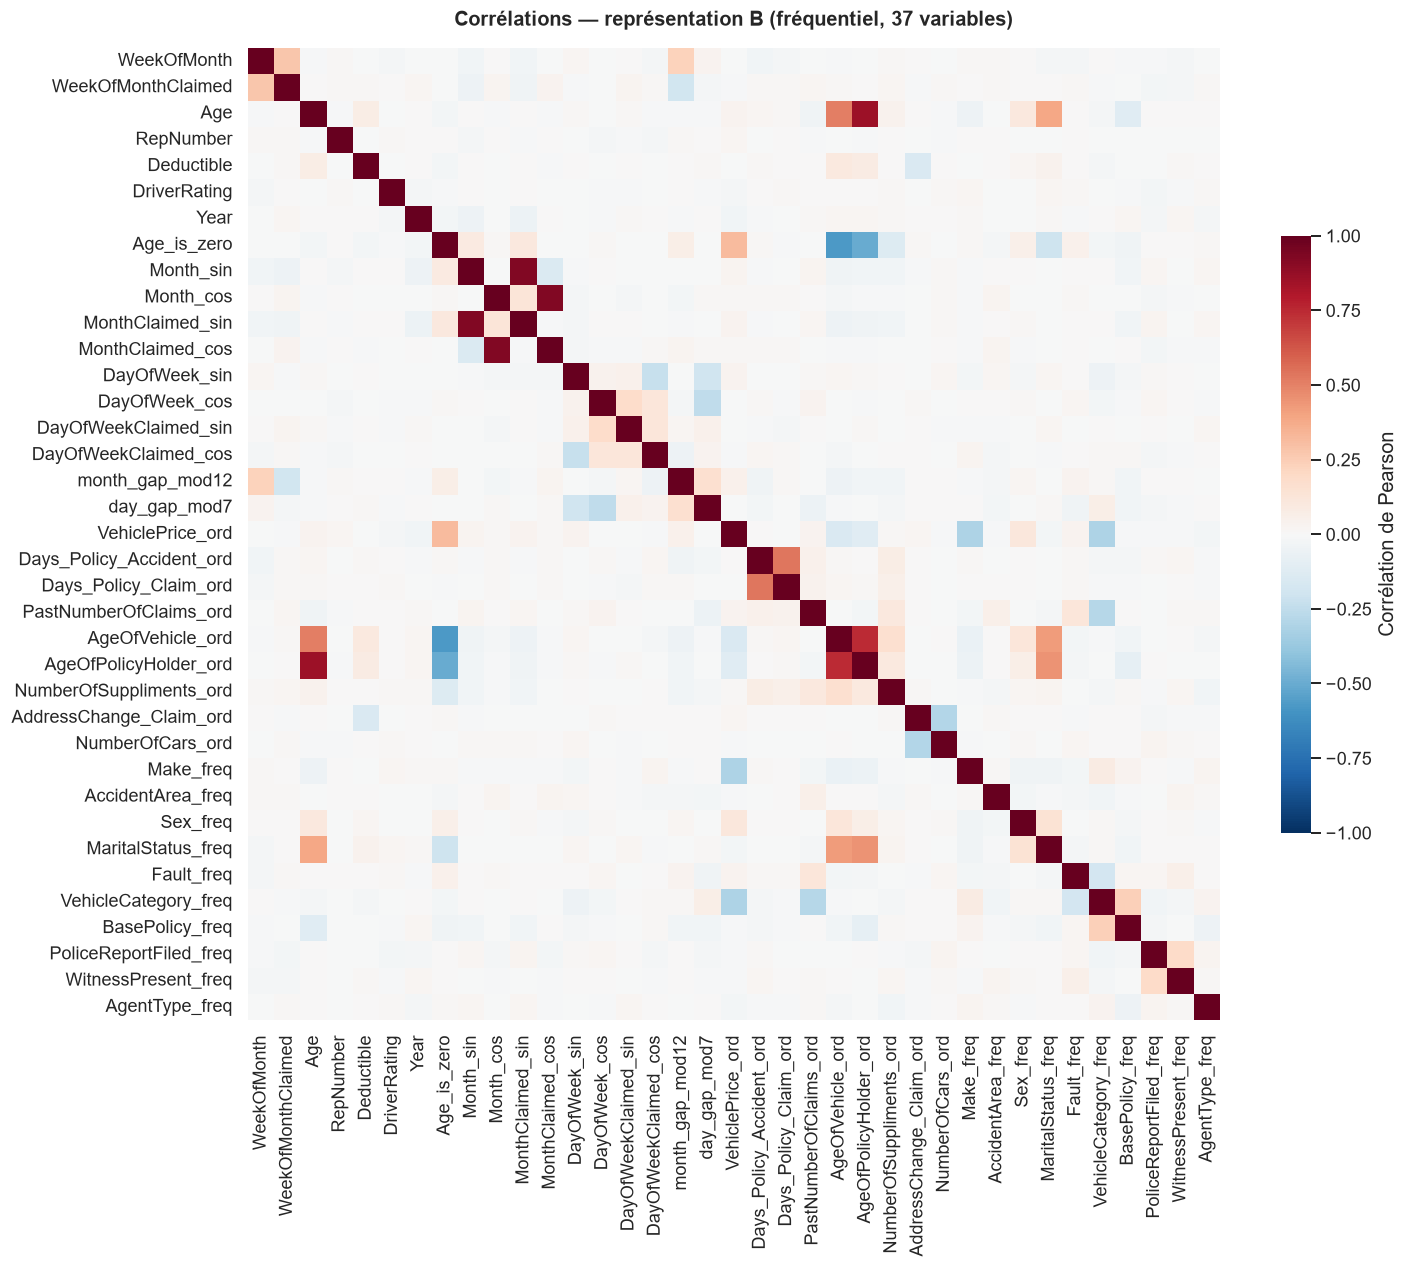

Paires les plus corrélées (|r|) :


,,|corr|
Month_sin,MonthClaimed_sin,0.9296
Month_cos,MonthClaimed_cos,0.9232
Age,AgeOfPolicyHolder_ord,0.8525
AgeOfVehicle_ord,AgeOfPolicyHolder_ord,0.7460
Age_is_zero,AgeOfVehicle_ord,0.5779
Days_Policy_Accident_ord,Days_Policy_Claim_ord,0.5346
Age,AgeOfVehicle_ord,0.5091
Age_is_zero,AgeOfPolicyHolder_ord,0.5028


In [13]:
# La représentation fréquentielle (compacte) reste-t-elle peu redondante ?
plt.figure(figsize=(13, 11))
corr = X_train_freq.corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': .6, 'label': 'Corrélation de Pearson'})
plt.title('Corrélations — représentation B (fréquentiel, 37 variables)', pad=14, fontweight='bold')
plt.tight_layout(); plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
         .abs().sort_values(ascending=False).head(8))
print('Paires les plus corrélées (|r|) :')
display(pairs.rename('|corr|').to_frame())

## 12. Persistance de la base de modélisation

On conserve la représentation retenue pour la modélisation — l'encodage **fréquentiel standardisé** — sous forme de quatre CSV (matrices train/test et cibles associées). Les autres représentations, calculées plus haut à des fins de comparaison, ne sont pas persistées.

In [14]:
def save(dframe, name):
    path = OUTPUT_DIR / name
    dframe.to_csv(path, index=False)
    return path.name, dframe.shape

outputs = {}
for frame, name in [
    (X_train_freq_scaled, 'X_train_freq_scaled.csv'),
    (X_test_freq_scaled, 'X_test_freq_scaled.csv'),
    (y_train.to_frame(TARGET), 'y_train.csv'),
    (y_test.to_frame(TARGET), 'y_test.csv'),
]:
    fname, shape = save(frame, name)
    outputs[fname] = shape


print('Fichiers finaux écrits :')
for k, v in outputs.items(): print(f'  {k:34s} {v}')

Fichiers finaux écrits :
  X_train_freq_scaled.csv            (11565, 37)
  X_test_freq_scaled.csv             (3855, 37)
  y_train.csv                        (11565, 1)
  y_test.csv                         (3855, 1)


## 13. Synthèse

La base de modélisation est prête et reproductible :

1. **Aucune fuite** : découpage avant apprentissage, transformations apprises ajustées sur le train uniquement, `handle_unknown='ignore'` pour les modalités inédites.
2. **Deux représentations comparables** (one-hot fidèle / fréquentiel compact), chacune en version brute et standardisée, pour couvrir les besoins d'Isolation Forest **et** de ses comparatifs LOF / One-Class SVM.
3. **Redondances traitées** : `PolicyType` supprimé (déterminé par `VehicleCategory` × `BasePolicy`), modalités rares de `Make` regroupées, variables temporelles encodées de façon cyclique plutôt que linéaire.
4. **Décisions EDA appliquées** : indicateur `Age == 0`, codes de date invalides recodés, quasi-constantes de délai conservées, mappings ordinaux documentés.
5. **Persistance ciblée** : la représentation retenue (fréquentiel standardisé) est enregistrée en CSV, prête pour la modélisation.

Prochaine étape (notebook de modélisation) : entraîner Isolation Forest sur les variantes brutes, LOF et One-Class SVM sur les variantes standardisées, puis évaluer hors échantillon avec ROC-AUC, PR-AUC, précision@k et lift@k, en comparant les représentations et en testant la sensibilité à `n_estimators` / `max_samples` / contamination.